In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

In [4]:
df = pd.read_csv("../dataset/career_recommender.csv")

df.head()

,What is your name?,What is your gender?,What was your course in UG?,What is your UG specialization? Major Subject (Eg; Mathematics),What are your interests?,What are your skills ? (Select multiple if necessary),What was the average CGPA or Percentage obtained in under graduation?,Did you do any certification courses additionally?,"If yes, please specify your certificate course title.",Are you working?,"If yes, then what is/was your first Job title in your current field of work? If not applicable, write NA.","Have you done masters after undergraduation? If yes, mention your field of masters.(Eg; Masters in Mathematics)"
0,A.Uha Priya,Female,B.Sc,Computer Applications,Cloud computing,Python;SQL;Java,85,Yes,"Linux,Git",Yes,Software,MCA
1,Aadil,Male,B.E,Computer Science Engineering,Technology,"Critical Thinking, Analytic Thinking, SQL, Pro...",66.5,Yes,Microsoft certification,Yes,Computer Software Engineer,NaN
2,Aakriti,Female,BA,Psychology,Understand human behaviour,People management;Communication skills,64.6,Yes,Resilience psychology,No,NaN,NaN
3,Aanchal sharma,Female,MBA,Commerce,Sales/Marketing;Trading;Understand human behav...,Accounting Skills;Critical Thinking,75.525,No,No,Yes,Relationships manager,NaN
4,Aangkeeta Sarkar,Female,B.Tech,Instrumentation Engineering,Technology,\r\nPLC Allen Bradley;PLC Ladder Logic;LabVIEW...,70.68,Yes,Extreme Productivity (Blinkist Summary),Yes,Plant Instrumentation Engineer,NaN


In [15]:
df.columns

Index(['What is your name?', 'What is your gender?',
       'What was your course in UG?',
       'What is your UG specialization? Major Subject (Eg; Mathematics)',
       'What are your interests?',
       'What are your skills ? (Select multiple if necessary)',
       'What was the average CGPA or Percentage obtained in under graduation?',
       'Did you do any certification courses additionally?',
       'If yes, please specify your certificate course title.',
       'Are you working?',
       'If yes, then what is/was your first Job title in your current field of work? If not applicable, write NA.               ',
       'Have you done masters after undergraduation? If yes, mention your field of masters.(Eg; Masters in Mathematics)'],
      dtype='object')

In [17]:
len(df.columns)

12

In [18]:
df.columns = [
    'name',
    'gender',
    'ug_course',
    'specialization',
    'interests',
    'skills',
    'cgpa',
    'certification',
    'certificate_course',
    'working',
    'masters',
    'career'
]

# Dataset Overview

In [5]:
df.shape

(1195, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 12 columns):
 #   Column                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                                    --------------  ----- 
 0   What is your name?                                                                                                        1195 non-null   object
 1   What is your gender?                                                                                                      1195 non-null   object
 2   What was your course in UG?                                                                                               1195 non-null   object
 3   What is your UG specialization? Major Subject (Eg; Mathematics)                                                           1195 non-null   

In [7]:
df.describe()

,What is your name?,What is your gender?,What was your course in UG?,What is your UG specialization? Major Subject (Eg; Mathematics),What are your interests?,What are your skills ? (Select multiple if necessary),What was the average CGPA or Percentage obtained in under graduation?,Did you do any certification courses additionally?,"If yes, please specify your certificate course title.",Are you working?,"If yes, then what is/was your first Job title in your current field of work? If not applicable, write NA.","Have you done masters after undergraduation? If yes, mention your field of masters.(Eg; Masters in Mathematics)"
count,1195,1195,1195,1195,1195,1194,1195,1195,1194,1195,899,469
unique,1161,3,59,295,615,1007,301,3,523,2,483,236
top,JITEN KUMAR BARIK,Male,B.Tech,Computer Science Engineering,Technology,NO,76,Yes,No,Yes,Student (Unemployed),Masters in Business Administration
freq,3,806,488,174,132,44,56,611,580,713,116,42


In [8]:
df.isnull().sum()

What is your name?                                                                                                            0
What is your gender?                                                                                                          0
What was your course in UG?                                                                                                   0
What is your UG specialization? Major Subject (Eg; Mathematics)                                                               0
What are your interests?                                                                                                      0
What are your skills ? (Select multiple if necessary)                                                                         1
What was the average CGPA or Percentage obtained in under graduation?                                                         0
Did you do any certification courses additionally?                                                      

# Data cleaning

In [9]:
df.dropna(inplace=True)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.isnull().sum()

What is your name?                                                                                                          0
What is your gender?                                                                                                        0
What was your course in UG?                                                                                                 0
What is your UG specialization? Major Subject (Eg; Mathematics)                                                             0
What are your interests?                                                                                                    0
What are your skills ? (Select multiple if necessary)                                                                       0
What was the average CGPA or Percentage obtained in under graduation?                                                       0
Did you do any certification courses additionally?                                                                    

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

# EDA (Exploratory Data Analysis)

### Career Distribution

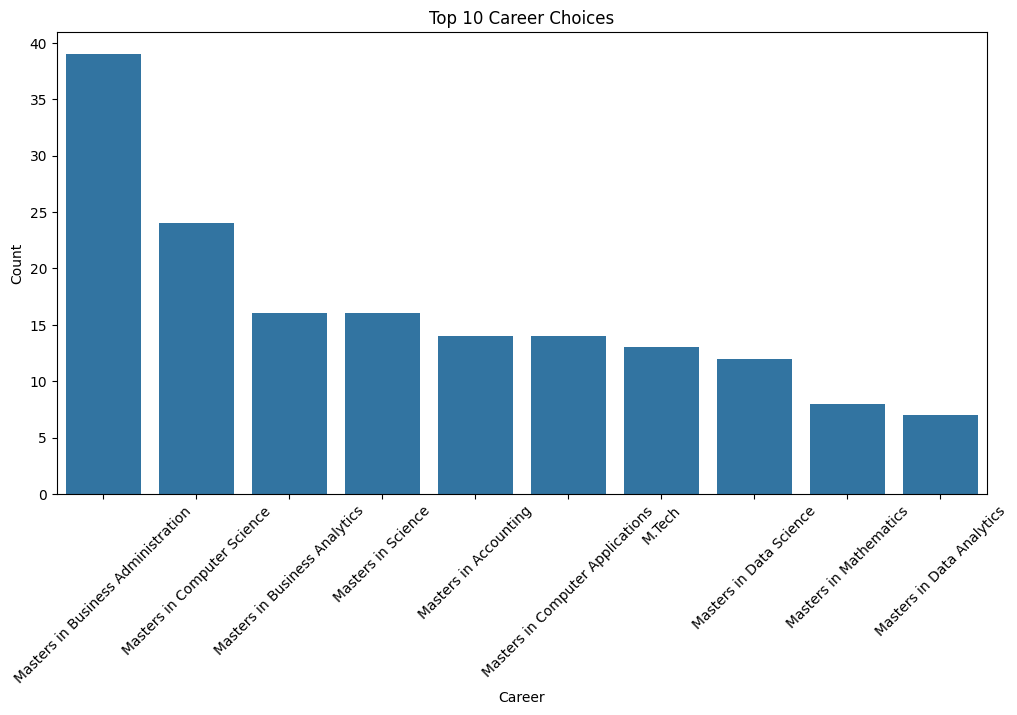

In [20]:
plt.figure(figsize=(12,6))
top_careers = df['career'].value_counts().head(10)
sns.barplot(
    x=top_careers.index,
    y=top_careers.values
)
plt.xticks(rotation=45)
plt.title("Top 10 Career Choices")
plt.xlabel("Career")
plt.ylabel("Count")
plt.show()

### Gender Distribution

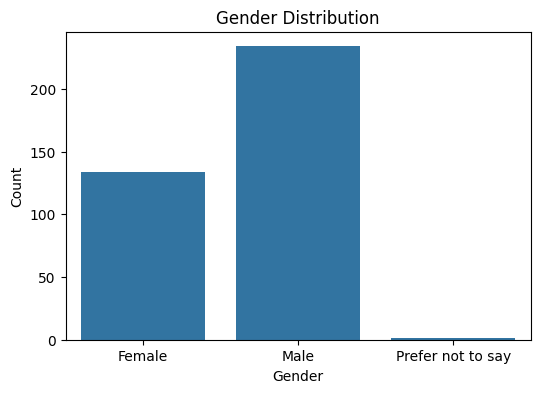

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [22]:
df['cgpa'] = pd.to_numeric(df['cgpa'], errors='coerce')

### CGPA Distribution

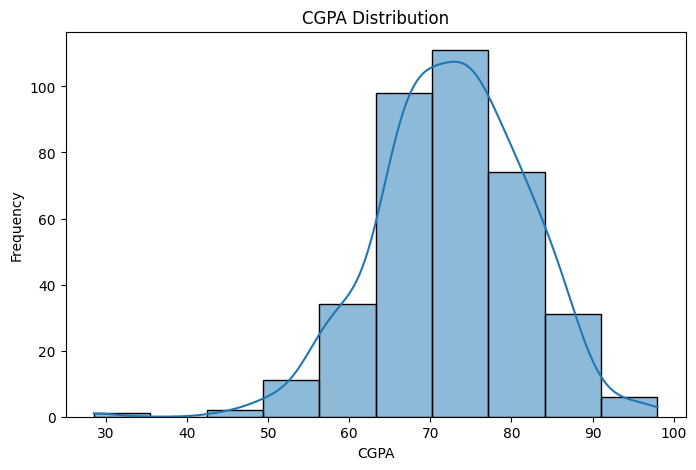

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['cgpa'], bins=10, kde=True)
plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()

### Top interests

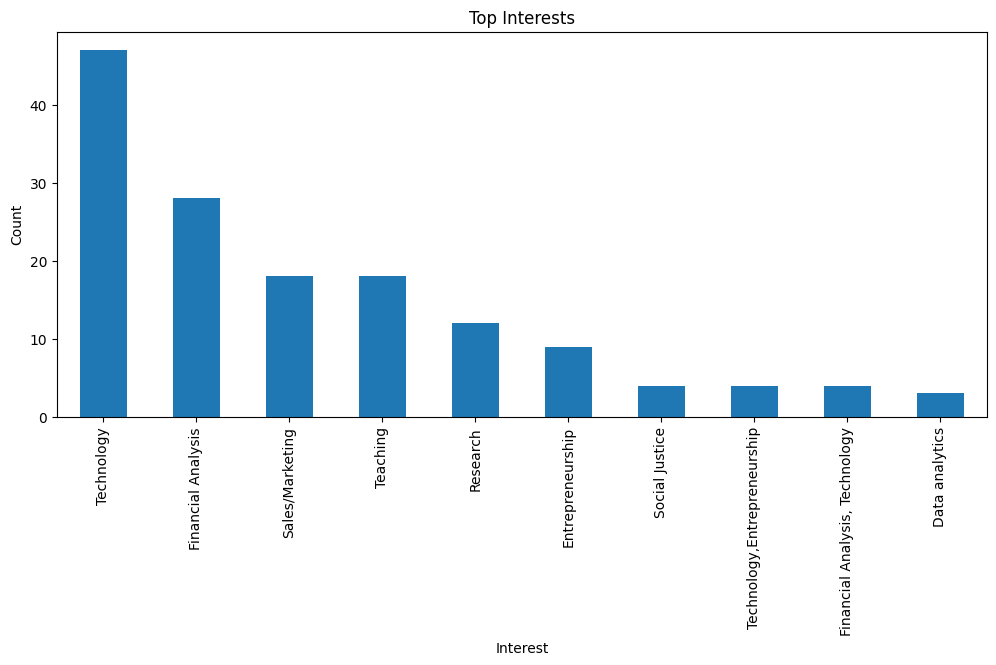

In [24]:
plt.figure(figsize=(12,5))
df['interests'].value_counts().head(10).plot(kind='bar')
plt.title("Top Interests")
plt.xlabel("Interest")
plt.ylabel("Count")
plt.show()

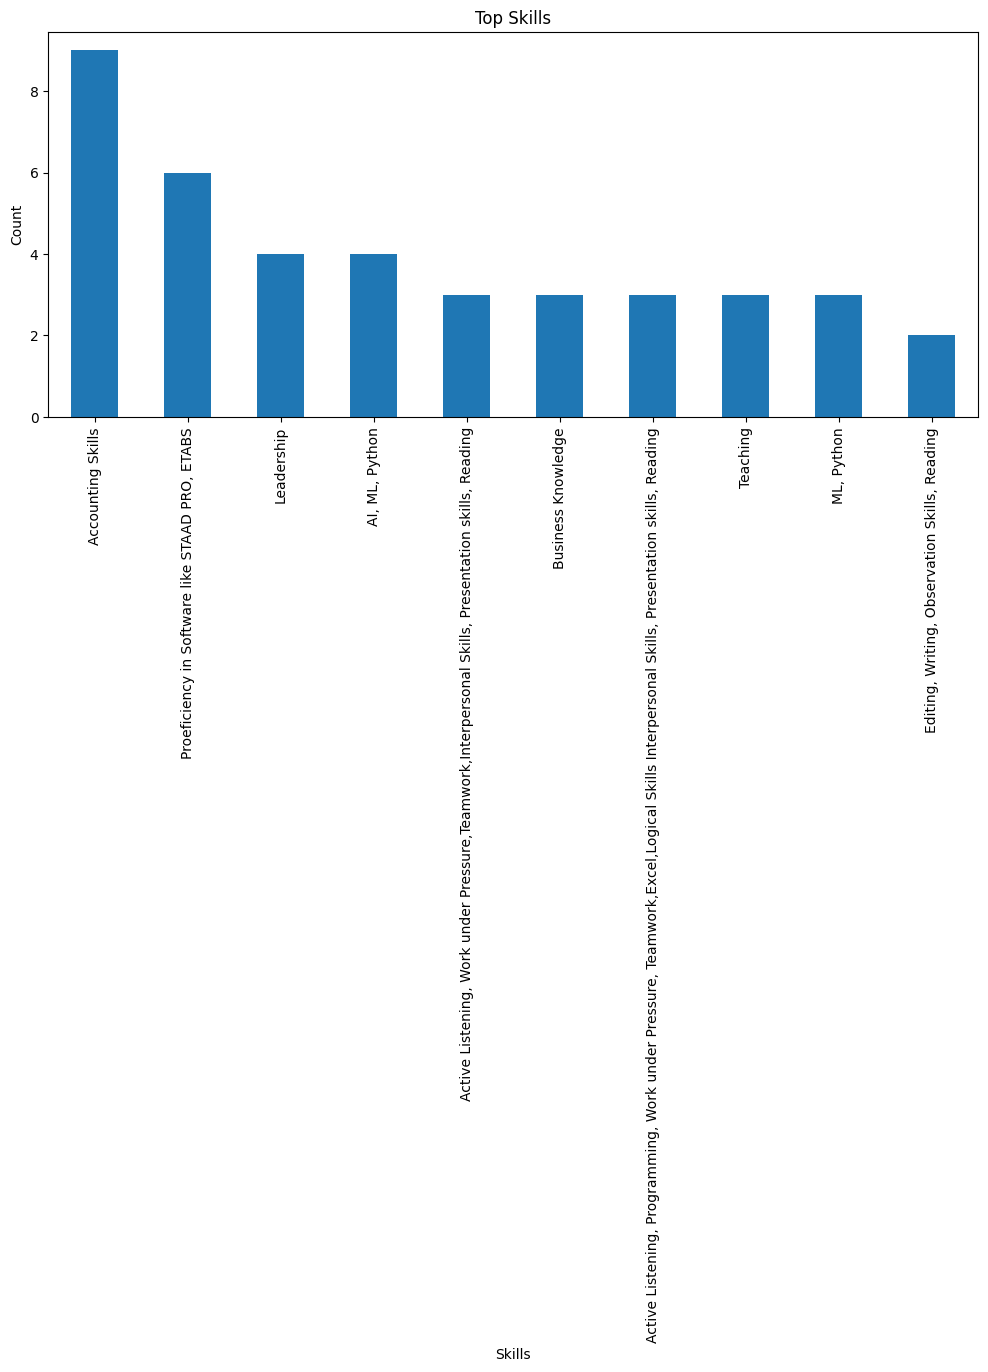

In [25]:
plt.figure(figsize=(12,5))
df['skills'].value_counts().head(10).plot(kind='bar')
plt.title("Top Skills")
plt.xlabel("Skills")
plt.ylabel("Count")
plt.show()

### Career Distribution by Gender

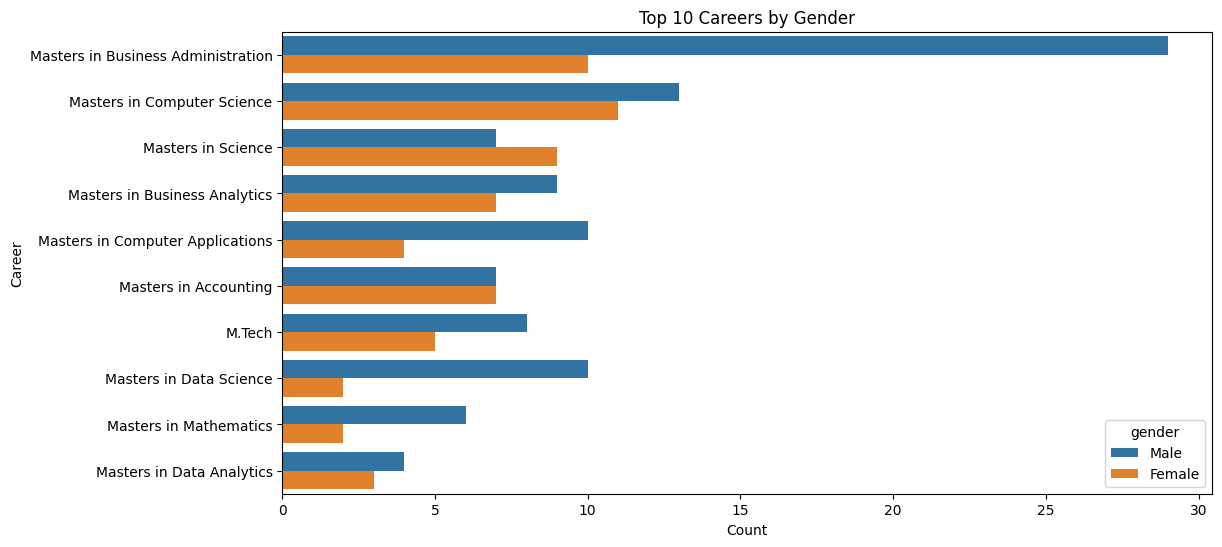

In [27]:
plt.figure(figsize=(12,6))
top_10_careers = df['career'].value_counts().head(10).index
filtered_df = df[df['career'].isin(top_10_careers)]
sns.countplot(
    data=filtered_df,
    y='career',
    hue='gender',
    order=filtered_df['career'].value_counts().index
)
plt.title("Top 10 Careers by Gender")
plt.xlabel("Count")
plt.ylabel("Career")
plt.show()

### Correlation Heatmap

In [32]:
from sklearn.preprocessing import LabelEncoder
heatmap_df = df.copy()

In [34]:
heatmap_df = df.drop('name', axis=1).copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in heatmap_df.columns:
    heatmap_df[col] = le.fit_transform(
        heatmap_df[col].astype(str)
    )

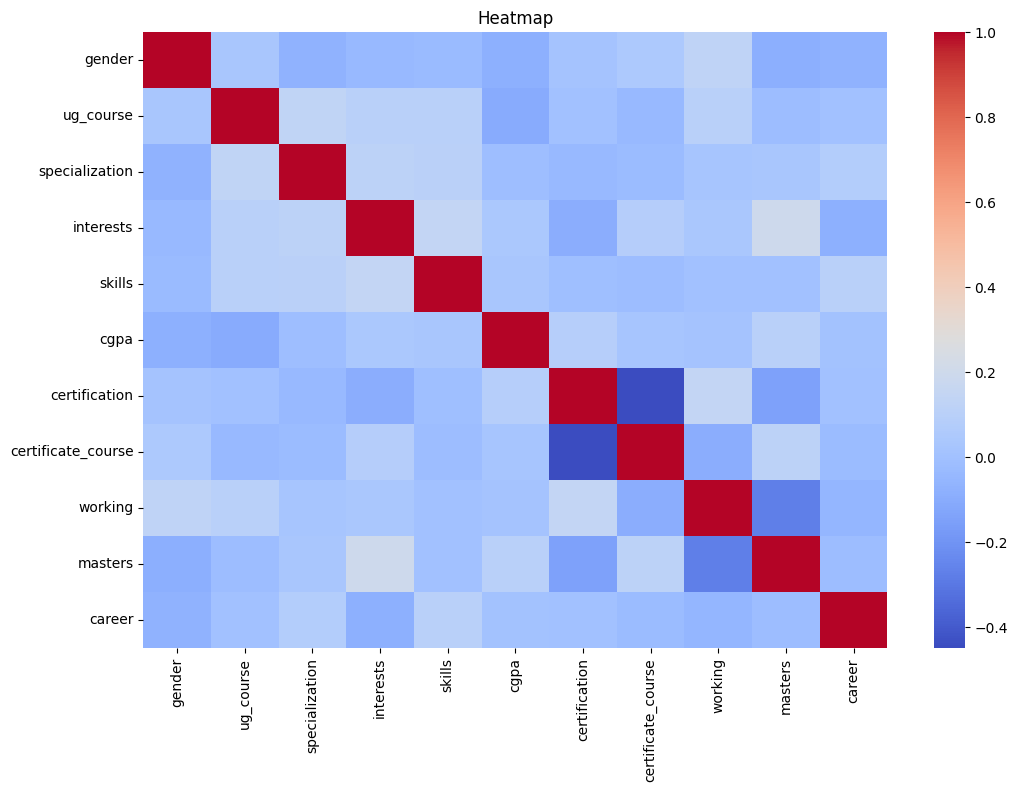

In [36]:
plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_df.corr(),
    cmap='coolwarm',
    annot=False
)
plt.title("Heatmap")
plt.show()

# Preprocessing and  Model Training

In [37]:
df = df.drop('name', axis=1)
df.head()

,gender,ug_course,specialization,interests,skills,cgpa,certification,certificate_course,working,masters,career
0,Female,B.Sc,Computer Applications,Cloud computing,Python;SQL;Java,85.000,Yes,"Linux,Git",Yes,Software,MCA
6,Male,BMS,Commerce,"Research, Sales/Marketing","Critical Thinking, Analytic Thinking, Communic...",73.150,No,No,No,Student (Unemployed),PGDM (Marketing)
10,Male,B.Com,Accountancy,Financial Analysis,"Accounting Skills, Analytic Thinking, Cost Acc...",63.745,Yes,Alteryx and Tableau,No,Tele-caller,Pursuing Certified Management Accountant of Un...
17,Male,BE,Mechanical Engineering,Entrepreneurship,"Python, Critical Thinking, Analytic Thinking, ...",71.250,Yes,Google Data Analytics Course,Yes,Teacher,M.Tech in Metallury and Material Science
19,Male,BE,Structural Engineeeing,Research;Teaching;Technology;Data analytics,Active Listening;Critical Thinking;Analytical ...,74.330,No,No,Yes,Assistant Professor,Master in Structural Engineering


### Encode Categorical Columns

In [ ]:
for col in df.columns:
    df[col] = le.fit_transform(df[col].astype(str))
df.head()   

,gender,ug_course,specialization,interests,skills,cgpa,certification,certificate_course,working,masters,career
0,0,41,53,112,222,26,1,10,1,56,117
6,1,9,48,202,91,106,0,32,0,66,61
10,1,23,1,125,246,60,1,171,0,81,70
17,1,7,114,124,203,98,1,162,1,73,97
19,1,7,19,30,315,115,0,32,1,172,132


### Define Features & Target

In [51]:
df['career'].value_counts()
df.reset_index(drop=True, inplace=True)

In [53]:
df.columns

Index(['gender', 'ug_course', 'specialization', 'interests', 'skills', 'cgpa',
       'certification', 'certificate_course', 'working', 'masters', 'career'],
      dtype='object')

In [ ]:
top_careers = df['career'].value_counts().head(15).index
df = df[df['career'].isin(top_careers)]

In [55]:
df.reset_index(drop=True, inplace=True)

In [111]:
from sklearn.preprocessing import LabelEncoder
encoders = {}
for col in df.columns:

    if df[col].dtype == 'object':

        le = LabelEncoder()

        df[col] = le.fit_transform(
            df[col].astype(str)
        )
    
        encoders[col] = le

In [112]:
import joblib

joblib.dump(
    encoders,
    "../model/label_encoder.pkl"
)
print("All encoders saved successfully!")

All encoders saved successfully!


In [109]:
X = df.drop('career', axis=1)
y = df['career']
from sklearn.preprocessing import LabelEncoder
career_encoder = LabelEncoder()
y = career_encoder.fit_transform(y)


In [97]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [114]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.41025641025641024


In [116]:
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print("Classification Report:\n")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:

              precision    recall  f1-score   support

           2       0.00      0.00      0.00         0
           3       0.33      0.33      0.33         3
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         1
           6       0.46      0.86      0.60         7
           7       0.67      0.50      0.57         4
           8       0.00      0.00      0.00         4
           9       0.44      0.50      0.47         8
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.25      0.50      0.33         2
          13       0.00      0.00      0.00         3
          14       1.00      0.67      0.80         3

    accuracy                           0.41        39
   macro avg       0.24      0.26      0.24        39
weighted avg       0.36      0.41      0.37        39



c:\Users\Harshitha\Desktop\smart-career-recommender\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Harshitha\Desktop\smart-career-recommender\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Harshitha\Desktop\smart-career-recommender\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

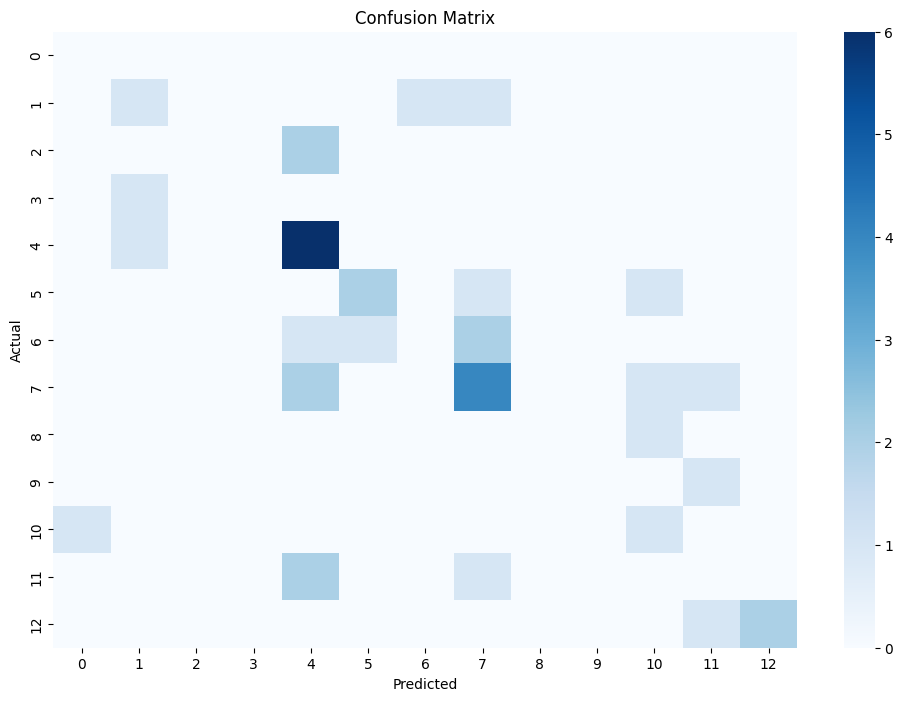

In [117]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(12,8))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [118]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': model.feature_importances_
})

importance = importance.sort_values(

    by='Importance',

    ascending=False
)

print(importance.head(10))

              Feature  Importance
3           interests    0.168184
4              skills    0.152767
5                cgpa    0.128732
2      specialization    0.125815
9             masters    0.123621
1           ug_course    0.106230
7  certificate_course    0.084556
0              gender    0.037925
8             working    0.036373
6       certification    0.035798


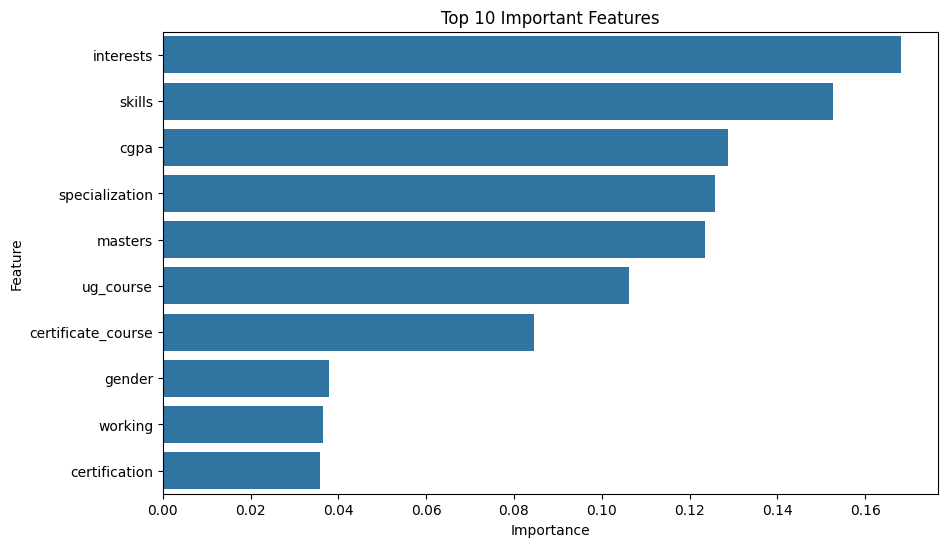

In [119]:
plt.figure(figsize=(10,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [100]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.41025641025641024


In [101]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)
importance

,Feature,Importance
0,gender,0.037925
1,ug_course,0.106230
2,specialization,0.125815
3,interests,0.168184
4,skills,0.152767
5,cgpa,0.128732
6,certification,0.035798
7,certificate_course,0.084556
8,working,0.036373
9,masters,0.123621


# saving the orgiginal Model

In [105]:
import joblib
joblib.dump(model, '../model/career_model.pkl')
print("Original model saved successfully!")

Original model saved successfully!


In [106]:
feature_columns = X.columns.tolist()
joblib.dump(
    feature_columns,
    '../model/feature_columns.pkl'
)

['../model/feature_columns.pkl']

In [107]:
feature_columns = X.columns.tolist()
joblib.dump(
    feature_columns,
    '../model/feature_columns.pkl'
)

['../model/feature_columns.pkl']

### SAVE LABEL ENCODER

In [108]:
joblib.dump(
    le,
    '../model/label_encoder.pkl'
)

['../model/label_encoder.pkl']